Data Downloading from kaggle

In [ ]:
import os
from zipfile import ZipFile

def download_and_extract_dataset(zip_url, output_dir, zip_path):

    if not os.path.exists(zip_path):
        print(f"Downloading dataset from:\n  {zip_url}")
        os.system(f'curl -L -o "{zip_path}" "{zip_url}"')
    else:
        print(f"Zip already exists: {zip_path}")

    if not os.path.exists(output_dir):
        print(f"Extracted to: {output_dir}")
        os.makedirs(output_dir, exist_ok=True)
        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(output_dir)
    else:
        print(f"Extracted: {output_dir}")



dataset_url  = "https://www.kaggle.com/api/v1/datasets/download/praveengovi/emotions-dataset-for-nlp"
zip_path     = "/content/emotions-nlp.zip"
extracted_path = "/content/data"

download_and_extract_dataset(dataset_url, extracted_path, zip_path)

  https://www.kaggle.com/api/v1/datasets/download/praveengovi/emotions-dataset-for-nlp
Extracted to: /content/data


Verifying the downloaded data

In [ ]:
os.listdir(extracted_path)

['val.txt', 'train.txt', 'test.txt']

In [ ]:
for f in os.listdir(extracted_path):
    fpath = os.path.join(extracted_path, f)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {f:<30}  {size:>8.1f} KB")

  val.txt                            199.5 KB
  train.txt                         1619.7 KB
  test.txt                           201.9 KB


Importing libraries

In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

In [ ]:
EMOTION_LABELS = ["joy", "sadness", "anger", "fear", "love", "surprise"]

In [ ]:
import pandas as pd

def load_txt_file(filepath: str) -> pd.DataFrame:
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            parts = line.rsplit(";", 1)
            print(parts)



            if len(parts) == 2:
                text, label = parts[0].strip(), parts[1].strip().lower()
                records.append({"text": text, "label": label})
            else:
                print(f"  [WARN] Skipping malformed line {line_num}: {line[:60]}")
    return pd.DataFrame(records)


def load_dataset(data_dir: str) -> pd.DataFrame:
    dfs = []

    for fname in ["train.txt", "val.txt", "test.txt"]:
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            data = load_txt_file(fpath)
            data["source_file"] = fname

            dfs.append(data)

    merged = pd.concat(dfs, ignore_index=True)

    return merged


print("Loading dataset")
df_raw = load_dataset('/content/data')

Loading dataset
['i didnt feel humiliated', 'sadness']
['i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'sadness']
['im grabbing a minute to post i feel greedy wrong', 'anger']
['i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'love']
['i am feeling grouchy', 'anger']
['ive been feeling a little burdened lately wasnt sure why that was', 'sadness']
['ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny', 'surprise']
['i feel as confused about life as a teenager or as jaded as a year old man', 'fear']
['i have been with petronas for years i feel that petronas has performed well and made a huge profit', 'joy']
['i feel romantic too', 'love']
['i feel like i have to make the suffering i m seeing mean something', 'sadness']
['i do feel that running is a divine experience and that i can expect to have some type of

In [ ]:

print(f"\n  Total rows loaded : {len(df_raw):,}")


  Total rows loaded : 20,000


In [ ]:
print(f"  Columns           : {list(df_raw.columns)}")

  Columns           : ['text', 'label', 'source_file']


In [ ]:
print(f"\n  Label counts:\n{df_raw['label'].value_counts()}")


  Label counts:
label
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64


In [ ]:
print(f"\n  Sample rows:")
print(df_raw.head(5).to_string(index=False))


  Sample rows:
                                                                                                        text   label source_file
                                                                                     i didnt feel humiliated sadness   train.txt
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake sadness   train.txt
                                                            im grabbing a minute to post i feel greedy wrong   anger   train.txt
                i am ever feeling nostalgic about the fireplace i will know that it is still on the property    love   train.txt
                                                                                        i am feeling grouchy   anger   train.txt


In [ ]:

n_dupes = df_raw.duplicated(subset=["text"]).sum()
print("Duplicate texts:", n_dupes)
df_clean = df_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)
print("After deduplication:", len(df_clean))

df_clean["label"] = df_clean["label"].str.lower().str.strip()
df_clean = df_clean[df_clean["label"].isin(EMOTION_LABELS)].reset_index(drop=True)
print("After label filtering:", len(df_clean))

df_clean["char_count"] = df_clean["text"].str.len()
df_clean["word_count"] = df_clean["text"].str.split().str.len()

print("Word count stats:")
print(df_clean.groupby("label")["word_count"].describe()[["mean","50%","std","min","max"]].round(1))

Duplicate texts: 52
After deduplication: 19948
After label filtering: 19948
Word count stats:
          mean   50%   std  min   max
label                                
anger     19.3  17.0  11.3  2.0  62.0
fear      18.7  16.0  10.9  2.0  60.0
joy       19.4  17.0  10.8  2.0  64.0
love      20.7  19.0  10.7  3.0  63.0
sadness   18.4  16.0  11.0  2.0  66.0
surprise  19.8  17.5  11.0  3.0  61.0


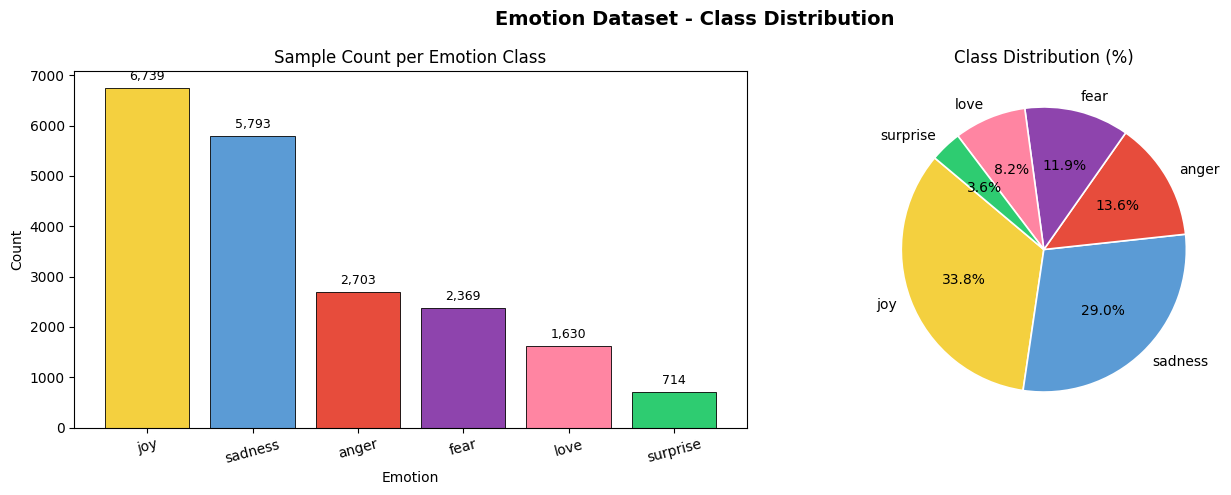

In [ ]:

label_counts = df_clean["label"].value_counts().reindex(EMOTION_LABELS)

EMOTION_COLOURS = {
    "joy":      "#F4D03F",
    "sadness":  "#5B9BD5",
    "anger":    "#E74C3C",
    "fear":     "#8E44AD",
    "love":     "#FF85A2",
    "surprise": "#2ECC71",
}

colours = [EMOTION_COLOURS[e] for e in EMOTION_LABELS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Emotion Dataset - Class Distribution", fontsize=14, fontweight="bold")

bars = axes[0].bar(EMOTION_LABELS, label_counts.values, color=colours, edgecolor="black", linewidth=0.6)
axes[0].set_title("Sample Count per Emotion Class")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f"{count:,}", ha="center", va="bottom", fontsize=9)

axes[1].pie(label_counts.values, labels=EMOTION_LABELS, colors=colours, autopct="%1.1f%%", startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.2})
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

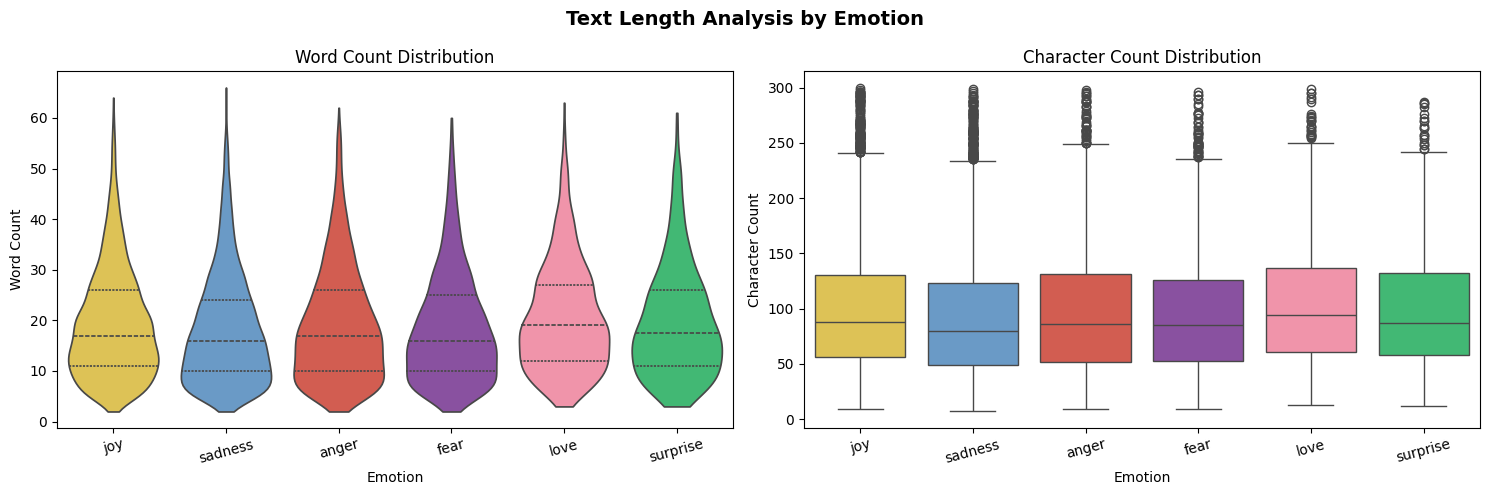

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Text Length Analysis by Emotion", fontsize=14, fontweight="bold")

sns.violinplot(data=df_clean, x="label", y="word_count", order=EMOTION_LABELS, palette=EMOTION_COLOURS, inner="quartile", ax=axes[0], cut=0)
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Word Count")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=df_clean, x="label", y="char_count", order=EMOTION_LABELS, palette=EMOTION_COLOURS, ax=axes[1])
axes[1].set_title("Character Count Distribution")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Character Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Device: cuda
Loading dataset …
  Total samples after cleaning: 19,948
label
joy         6739
sadness     5793
anger       2703
fear        2369
love        1630
surprise     714
Name: count, dtype: int64

Split sizes → train: 13,963 | val: 2,992 | test: 2,993

  Training baseline: bert-base  (bert-base-uncased)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4  train_loss=0.8765  train_f1=0.5756  val_loss=0.2402  val_f1=0.8953
  Epoch 2/4  train_loss=0.1850  train_f1=0.9018  val_loss=0.1695  val_f1=0.8986
  Epoch 3/4  train_loss=0.1165  train_f1=0.9263  val_loss=0.1475  val_f1=0.9031
  Epoch 4/4  train_loss=0.0850  train_f1=0.9407  val_loss=0.1460  val_f1=0.9025

  ── Test Results (distilbert) ──
  Accuracy : 0.9318
  Macro F1 : 0.9021
              precision    recall  f1-score   support

         joy     0.9356    0.9310    0.9333       406
     sadness     0.9443    0.8567    0.8984       356
       anger     0.9469    0.9525    0.9497      1011
        fear     0.8219    0.8320    0.8269       244
        love     0.9633    0.9678    0.9656       869
    surprise     0.7674    0.9252    0.8390       107

    accuracy                         0.9318      2993
   macro avg     0.8966    0.9109    0.9021      2993
weighted avg     0.9332    0.9318    0.9320      2993


  BASELINE COMPARISON SUMMARY
       Model  Test Accuracy  Ma

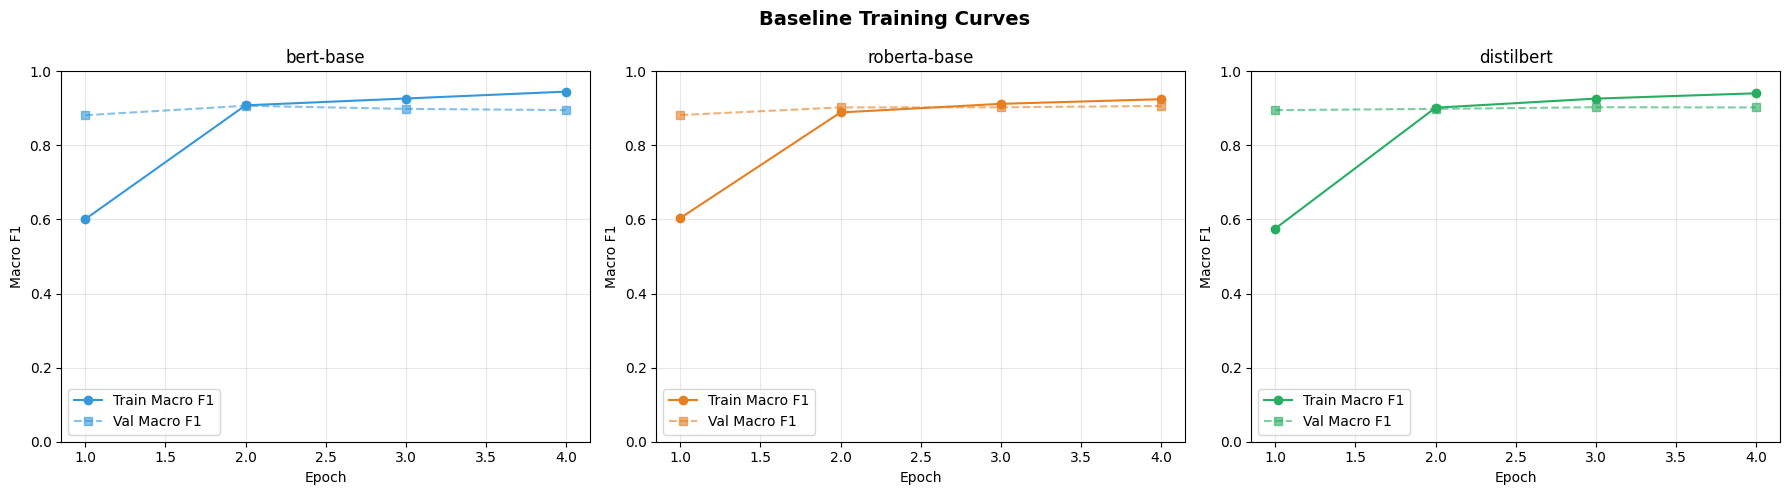

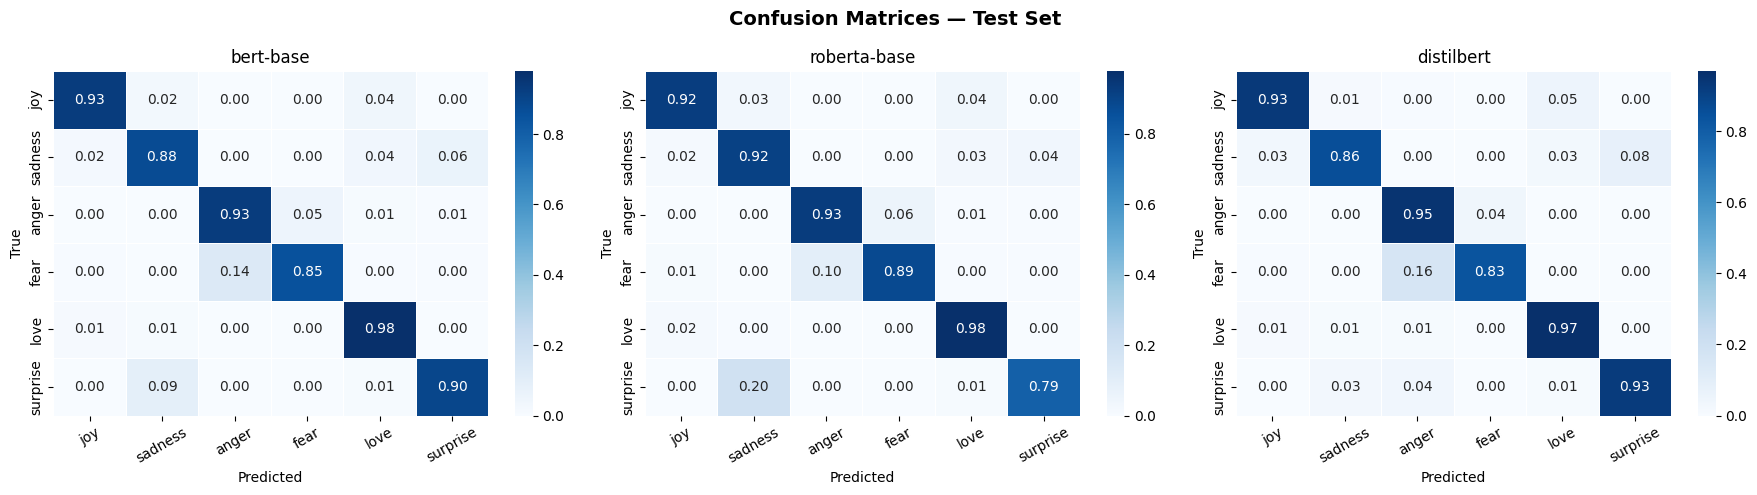

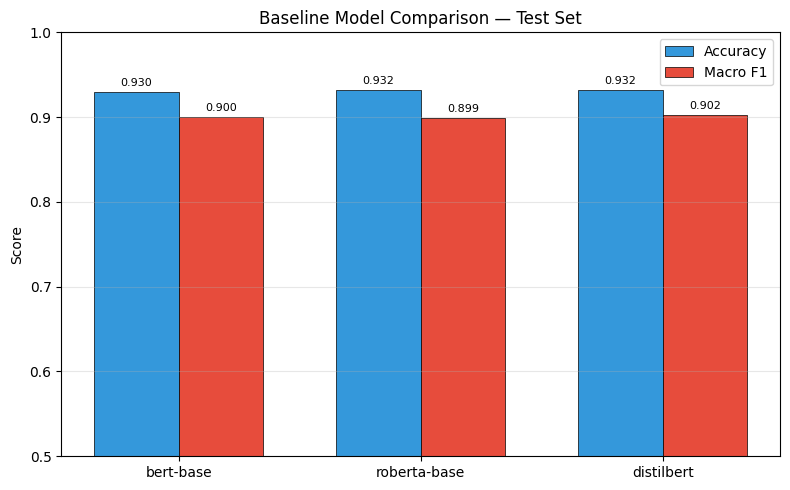


All baseline experiments complete.
Saved checkpoints to /content/{model_key}_best.pt
Saved plots to /content/baseline_*.png


In [ ]:

import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

# Config
EMOTION_LABELS  = ["joy", "sadness", "anger", "fear", "love", "surprise"]
MAX_LEN         = 128
BATCH_SIZE      = 32
EPOCHS          = 4
LEARNING_RATE   = 2e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODELS = {
    "bert-base":     "bert-base-uncased",
    "roberta-base":  "roberta-base",
    "distilbert":    "distilbert-base-uncased",
}

print(f"Device: {DEVICE}")

# 1. Load & clean data

def load_txt_file(filepath: str) -> pd.DataFrame:
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit(";", 1)
            if len(parts) == 2:
                text, label = parts[0].strip(), parts[1].strip().lower()
                records.append({"text": text, "label": label})
    return pd.DataFrame(records)


def load_dataset(data_dir: str) -> pd.DataFrame:
    dfs = []
    for fname in ["train.txt", "val.txt", "test.txt"]:
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            dfs.append(load_txt_file(fpath))
    return pd.concat(dfs, ignore_index=True)


print("Loading dataset …")
df_raw   = load_dataset("/content/data")
df_clean = df_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)
df_clean["label"] = df_clean["label"].str.lower().str.strip()
df_clean = df_clean[df_clean["label"].isin(EMOTION_LABELS)].reset_index(drop=True)
print(f"  Total samples after cleaning: {len(df_clean):,}")
print(df_clean["label"].value_counts())

# 2. Stratified 70 / 15 / 15 split

le = LabelEncoder()
le.fit(EMOTION_LABELS)
df_clean["label_id"] = le.transform(df_clean["label"])

train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean["label_id"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED
)

print(f"\nSplit sizes → train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")

# 3. PyTorch Dataset

class EmotionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.texts  = dataframe["text"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            # DistilBERT has no token_type_ids — handled via pop in train loop
            "token_type_ids": enc.get("token_type_ids", torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# 4. Training & evaluation helpers

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}
        if hasattr(model.config, "type_vocab_size") and model.config.type_vocab_size > 0:
            kwargs["token_type_ids"] = batch["token_type_ids"].to(device)

        outputs = model(**kwargs)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds  = outputs.logits.argmax(dim=-1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(labels_all, preds_all)
    f1       = f1_score(labels_all, preds_all, average="macro")
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}
        if hasattr(model.config, "type_vocab_size") and model.config.type_vocab_size > 0:
            kwargs["token_type_ids"] = batch["token_type_ids"].to(device)

        outputs = model(**kwargs)
        total_loss += outputs.loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(labels_all, preds_all)
    f1       = f1_score(labels_all, preds_all, average="macro")
    return avg_loss, acc, f1, preds_all, labels_all

# 5. Full training run for one architecture

def run_baseline(model_key, model_name, train_df, val_df, test_df):
    print(f"\n{'='*60}")
    print(f"  Training baseline: {model_key}  ({model_name})")
    print(f"{'='*60}")
    set_seed()

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(EMOTION_LABELS)
    ).to(DEVICE)

    train_ds = EmotionDataset(train_df, tokenizer)
    val_ds   = EmotionDataset(val_df,   tokenizer)
    test_ds  = EmotionDataset(test_df,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    total_steps   = len(train_loader) * EPOCHS
    warmup_steps  = int(total_steps * WARMUP_RATIO)

    optimizer  = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler  = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {"train_loss": [], "train_acc": [], "train_f1": [],
               "val_loss":   [], "val_acc":   [], "val_f1":   []}
    best_val_f1   = 0.0
    best_ckpt     = f"/content/{model_key}_best.pt"

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, DEVICE)

        history["train_loss"].append(tr_loss);  history["train_acc"].append(tr_acc)
        history["train_f1"].append(tr_f1);      history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc);      history["val_f1"].append(vl_f1)

        print(f"  Epoch {epoch}/{EPOCHS}  "
              f"train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  "
              f"val_loss={vl_loss:.4f}  val_f1={vl_f1:.4f}")

        if vl_f1 > best_val_f1:
            best_val_f1 = vl_f1
            torch.save(model.state_dict(), best_ckpt)

    # Load best checkpoint and test
    model.load_state_dict(torch.load(best_ckpt))
    te_loss, te_acc, te_f1, te_preds, te_labels = evaluate(model, test_loader, DEVICE)

    print(f"\n  ── Test Results ({model_key}) ──")
    print(f"  Accuracy : {te_acc:.4f}")
    print(f"  Macro F1 : {te_f1:.4f}")
    print(classification_report(te_labels, te_preds, target_names=EMOTION_LABELS, digits=4))

    return {
        "model_key": model_key,
        "history":   history,
        "test_acc":  te_acc,
        "test_f1":   te_f1,
        "preds":     te_preds,
        "labels":    te_labels,
        "model":     model,
        "tokenizer": tokenizer,
    }

# 6. Run all baselines

results = {}
for key, name in MODELS.items():
    results[key] = run_baseline(key, name, train_df, val_df, test_df)

# 7. Summary table

print("\n" + "="*50)
print("  BASELINE COMPARISON SUMMARY")
print("="*50)
summary = pd.DataFrame([
    {"Model": k, "Test Accuracy": v["test_acc"], "Macro F1": v["test_f1"]}
    for k, v in results.items()
])
print(summary.to_string(index=False))

# 8. Plots

EMOTION_COLOURS = {
    "joy": "#F4D03F", "sadness": "#5B9BD5", "anger": "#E74C3C",
    "fear": "#8E44AD", "love": "#FF85A2", "surprise": "#2ECC71",
}
MODEL_COLOURS = {"bert-base": "#3498DB", "roberta-base": "#E67E22", "distilbert": "#27AE60"}

# 8a. Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Baseline Training Curves", fontsize=14, fontweight="bold")

for ax, (key, res) in zip(axes, results.items()):
    epochs_x = range(1, EPOCHS + 1)
    ax.plot(epochs_x, res["history"]["train_f1"], "o-", label="Train Macro F1", color=MODEL_COLOURS[key])
    ax.plot(epochs_x, res["history"]["val_f1"],   "s--", label="Val Macro F1",  color=MODEL_COLOURS[key], alpha=0.6)
    ax.set_title(key)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/baseline_training_curves.png", dpi=150)
plt.show()

# 8b. Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold")

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                cmap="Blues", linewidths=0.5)
    ax.set_title(key)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/content/baseline_confusion_matrices.png", dpi=150)
plt.show()

# 8c. Bar chart comparing models
fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(results))
width = 0.35
keys  = list(results.keys())
accs  = [results[k]["test_acc"] for k in keys]
f1s   = [results[k]["test_f1"]  for k in keys]

bars1 = ax.bar(x - width/2, accs, width, label="Accuracy", color="#3498DB", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, f1s,  width, label="Macro F1",  color="#E74C3C", edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(keys)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.set_title("Baseline Model Comparison — Test Set")
ax.legend(); ax.grid(axis="y", alpha=0.3)

for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/content/baseline_model_comparison.png", dpi=150)
plt.show()

print("\nAll baseline experiments complete.")
print("Saved checkpoints to /content/{model_key}_best.pt")
print("Saved plots to /content/baseline_*.png")